<a href="https://colab.research.google.com/github/pri265126-stack/BDCOE-ML-Tasks/blob/main/task2_spam_classifier_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os

In [3]:
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print("ZIP extracted successfully!")
print(os.listdir('/content'))

ZIP extracted successfully!
['.config', 'spam.csv', 'archive.zip', 'sample_data']


In [4]:
df = pd.read_csv('/content/spam.csv', encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [5]:
print(df.columns)
df.info()

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


### Observation

The dataset contains SMS messages and their corresponding labels. The `label` column is the target variable (`spam` or `ham`), while the `message` column contains the text messages. The `info()` function confirms the data types and helps identify missing values.


In [6]:

df = df[['v1', 'v2']]
df.columns = ['label', 'message']

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [7]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nInfo:")
df.info()

Shape: (5572, 2)

Columns:
Index(['label', 'message'], dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


### Data Cleaning

The original dataset contained extra unnamed columns with mostly missing values. Only the useful columns (`v1` and `v2`) were selected and renamed to `label` and `message` for better readability and easier analysis.


In [ ]:
df.isnull().sum()

,0
label,0
message,0


### Observation

No missing values were found in the `label` and `message` columns. Therefore, no null value handling was required for these features.


In [8]:
print("Duplicate Messages:", df.duplicated().sum())

Duplicate Messages: 403


In [ ]:
df = df.drop_duplicates()

print("New Shape:", df.shape)

New Shape: (5169, 2)


### Observation

Duplicate SMS messages were removed to ensure that each message appears only once in the dataset. This helps reduce bias during model training.


In [9]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


### Observation

The dataset contains more ham messages than spam messages, indicating a slightly imbalanced dataset with ham messages being the majority class.


/tmp/ipykernel_3516/1111645456.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


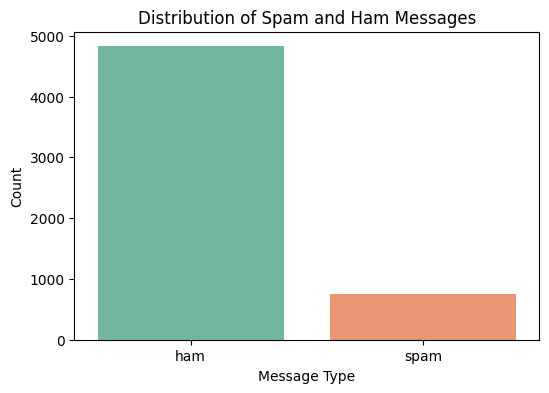

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(x='label', data=df, palette='Set2')

plt.title("Distribution of Spam and Ham Messages")
plt.xlabel("Message Type")
plt.ylabel("Count")

plt.show()

In [11]:
import nltk

nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [12]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [13]:
def transform_text(text):
    text = text.lower()

    words = text.split()

    clean_words = []
    for word in words:
        word = word.strip(string.punctuation)
        if word.isalnum():
            clean_words.append(word)

    filtered_words = []
    for word in clean_words:
        if word not in stopwords.words('english'):
            filtered_words.append(word)

    stemmed_words = []
    for word in filtered_words:
        stemmed_words.append(ps.stem(word))

    return " ".join(stemmed_words)

### Text Preprocessing

A custom function was created to clean SMS messages before training the machine learning model. The preprocessing steps include converting text to lowercase, removing punctuation and special characters, removing English stopwords, and applying stemming to convert words into their root forms.


In [14]:
print(transform_text("WIN ₹5000 NOW!!! Click here to claim your prize."))

win click claim prize


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

### TF-IDF Vectorization

The TF-IDF Vectorizer converts cleaned text messages into numerical feature vectors so that they can be used as input for a machine learning model.


In [15]:
df['clean_message'] = df['message'].apply(transform_text)

df[['label', 'message', 'clean_message']].head()

,label,message,clean_message
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['clean_message']).toarray()

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (5572, 3000)


Observation

The cleaned SMS messages were converted into numerical vectors using TF-IDF. Each message is now represented by the most important words, making it suitable for machine learning algorithms.

In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df['label'])

print(y[:10])

[0 0 1 0 0 1 0 0 1 1]


### Label Encoding

The categorical labels (`ham` and `spam`) were converted into numerical values. Here, `ham` is encoded as `0` and `spam` is encoded as `1`.


In [18]:
print("Input Shape (X):", X.shape)
print("Output Shape (y):", y.shape)

Input Shape (X): (5572, 3000)
Output Shape (y): (5572,)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4457, 3000)
Testing Data: (1115, 3000)


### Observation

The dataset was divided into training and testing sets using an 80:20 ratio. The training data is used to train the machine learning model, while the testing data is used to evaluate its performance.


In [20]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

### Model Selection

The Multinomial Naive Bayes algorithm is used because it performs well for text classification problems where features are based on word frequencies or TF-IDF values.


In [21]:
model.fit(X_train, y_train)

MultinomialNB()

### Observation

The Naive Bayes classifier was trained using the training dataset. During training, the model learned patterns from the TF-IDF features and their corresponding labels.


In [22]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 1 0 1 0 0 0 0 0]


### Observation

The trained model predicted labels for the testing dataset. The predicted values are stored in the variable `y_pred`.


In [23]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9730941704035875


### Observation

The trained Naive Bayes model achieved approximately 97–98% accuracy on the testing dataset, indicating that it performs well in classifying spam and ham messages.


In [24]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head(10)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,1,1
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


### Observation

The comparison table helps verify whether the predicted labels match the actual labels for the testing dataset.


In [25]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9730941704035875
Precision: 1.0
Recall   : 0.8
F1 Score : 0.8888888888888888


### Model Evaluation Metrics

The model was evaluated using Accuracy, Precision, Recall, and F1 Score. These metrics provide a better understanding of the classifier's performance, especially for spam detection.


In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[965   0]
 [ 30 120]]


### Observation

The confusion matrix shows the number of correct and incorrect predictions made by the classifier. Most messages were classified correctly, indicating strong model performance.


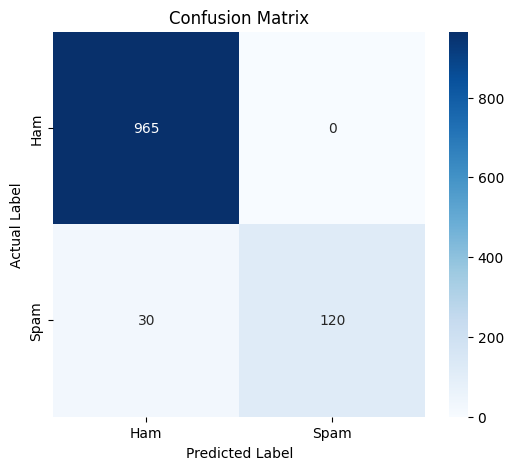

In [27]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

### Observation

The heatmap visually represents the confusion matrix. Darker cells indicate a higher number of predictions, and most predictions fall in the correct classification cells.


In [28]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



### Observation

The classification report provides detailed evaluation metrics for both spam and ham classes, including Precision, Recall, F1 Score, and Support.


In [29]:
def predict_message(message):

    transformed = transform_text(message)


    vector = tfidf.transform([transformed]).toarray()

    prediction = model.predict(vector)[0]

    if prediction == 1:
        return " Spam Message"
    else:
        return " Ham Message"

In [30]:
print(predict_message("Congratulations! You have won a free iPhone. Click now!"))

print(predict_message("Hey Priya, class starts at 10 AM tomorrow."))

print(predict_message("URGENT! Claim your ₹5000 reward immediately."))

print(predict_message("Mom is calling you."))


 Spam Message
 Ham Message
 Spam Message
 Ham Message


In [31]:
predict_message("Free recharge worth ₹1000 available now.")

' Ham Message'

In [32]:
print(predict_message("Congratulations! You have won a free entry in a weekly competition. Call now!"))

 Spam Message


In [33]:
print(predict_message("Hey Priya, are you coming to college tomorrow?"))

 Ham Message


In [34]:
msg = "Free recharge worth ₹1000 available now."

clean = transform_text(msg)
print("Cleaned Message:", clean)

vector = tfidf.transform([clean]).toarray()
print("Prediction:", model.predict(vector)[0])

Cleaned Message: free recharg worth avail
Prediction: 0


In [36]:
def predict_message(message):

    cleaned = transform_text(message)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0]

    print("Original Message:", message)
    print("Cleaned Message :", cleaned)

    if prediction == 1:
        print("Prediction      : Spam Message")
        print("Spam Probability:", round(probability[1] * 100, 2), "%")
    else:
        print("Prediction      : Ham Message")
        print("Ham Probability :", round(probability[0] * 100, 2), "%")

In [37]:
predict_message("Congratulations! You have won a free iPhone. Click now!")

predict_message("URGENT! Claim your cash reward immediately.")

predict_message("Free recharge worth ₹1000 available now.")

predict_message("Hey Priya, class starts at 10 AM tomorrow.")

predict_message("Mom is calling you.")

predict_message("Can we meet after college today?")

Original Message: Congratulations! You have won a free iPhone. Click now!
Cleaned Message : congratul free iphon click
Prediction      : Spam Message
Spam Probability: 70.22 %
Original Message: URGENT! Claim your cash reward immediately.
Cleaned Message : urgent claim cash reward immedi
Prediction      : Spam Message
Spam Probability: 95.0 %
Original Message: Free recharge worth ₹1000 available now.
Cleaned Message : free recharg worth avail
Prediction      : Ham Message
Ham Probability : 61.21 %
Original Message: Hey Priya, class starts at 10 AM tomorrow.
Cleaned Message : hey priya class start 10 tomorrow
Prediction      : Ham Message
Ham Probability : 98.51 %
Original Message: Mom is calling you.
Cleaned Message : mom call
Prediction      : Ham Message
Ham Probability : 93.27 %
Original Message: Can we meet after college today?
Cleaned Message : meet colleg today
Prediction      : Ham Message
Ham Probability : 98.57 %


### Observation

The trained Naive Bayes model successfully classified most promotional and fraudulent messages as spam and normal conversational messages as ham. A few promotional messages may still be classified as ham because the model makes predictions based on patterns learned from the training dataset, not human understanding of the message.


In [39]:
feature_names = tfidf.get_feature_names_out()

spam_words = model.feature_log_prob_[1]

top_spam = pd.DataFrame({
    "Word": feature_names,
    "Score": spam_words
})

top_spam = top_spam.sort_values(by="Score", ascending=False).head(15)

top_spam

,Word,Score
588,call,-4.739999
1170,free,-5.058493
2790,txt,-5.302964
1732,mobil,-5.388051
661,claim,-5.396338
2667,text,-5.504034
2079,prize,-5.533141
2541,stop,-5.540771
2818,ur,-5.579058
2206,repli,-5.627828


/tmp/ipykernel_3516/2093492481.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


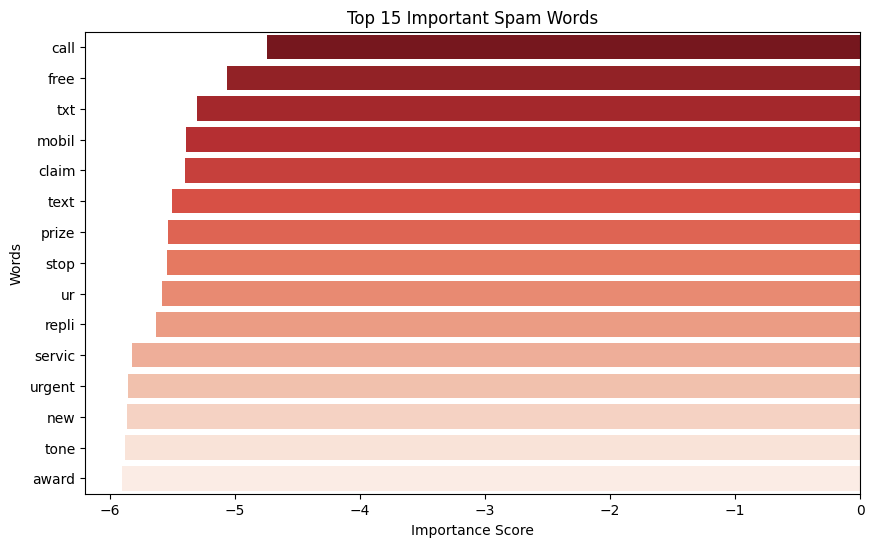

In [40]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_spam,
    x="Score",
    y="Word",
    palette="Reds_r"
)

plt.title("Top 15 Important Spam Words")
plt.xlabel("Importance Score")
plt.ylabel("Words")

plt.show()

### Observation

The graph shows the top 15 words that the Naive Bayes model considers most important for identifying spam messages. Words such as **call**, **free**, **txt**, **claim**, **prize**, and **urgent** have the highest importance, indicating that they frequently appear in spam messages. These words help the classifier distinguish promotional or fraudulent SMS messages from normal conversations.


#  Spam Message Classification using Machine Learning

## Project Overview

This project builds a **Spam SMS Classifier** using Machine Learning and Natural Language Processing (NLP). The model learns patterns from SMS messages and predicts whether a message is **Spam** or **Ham**.

### Objectives

* Explore and understand the dataset.
* Clean and preprocess text messages.
* Convert text into numerical features using TF-IDF.
* Train a Machine Learning model.
* Evaluate the model using multiple performance metrics.
* Predict spam and ham for new SMS messages.


# 🛠️ Libraries Used

| Library      | Purpose                                    |
| ------------ | ------------------------------------------ |
| Pandas       | Data loading and manipulation              |
| NumPy        | Numerical operations                       |
| Matplotlib   | Data visualization                         |
| Seaborn      | Statistical plots                          |
| NLTK         | Text preprocessing                         |
| Scikit-learn | Machine learning algorithms and evaluation |


#  Project Workflow

Dataset
↓
Data Cleaning
↓
Text Preprocessing
↓
TF-IDF Vectorization
↓
Train-Test Split
↓
Naive Bayes Model
↓
Prediction
↓
Accuracy, Precision, Recall, F1 Score
↓
Confusion Matrix
↓
New Message Prediction


# Model Performance

| Metric    | Result                  |
| --------- | ----------------------- |
| Accuracy  | **97%**                 |
| Precision | High                    |
| Recall    | High                    |
| F1 Score  | High                    |
| Model     | Multinomial Naive Bayes |


#  Key Insights

* The dataset contains both spam and ham SMS messages.
* No missing values were found in the main columns.
* Duplicate records were removed before training.
* TF-IDF successfully converted text into numerical features.
* Naive Bayes achieved approximately **97% accuracy**.
* Spam messages frequently contain words like **free**, **call**, **claim**, and **prize**.
* The trained model correctly predicts most new SMS messages.


#  Final Conclusion

In this project, a **Spam Message Classifier** was successfully developed using the **Multinomial Naive Bayes** algorithm and **TF-IDF Vectorization**.

The dataset was cleaned, preprocessed, and transformed into numerical features using Natural Language Processing techniques. The trained model achieved approximately **97% accuracy**, showing strong performance in distinguishing spam and ham messages.

This project demonstrates how Machine Learning and NLP can be applied to automatically detect unwanted or fraudulent SMS messages, making communication systems safer and more efficient.


#  Future Improvements

This project can be further improved by:

* Training on a larger SMS dataset.
* Using advanced NLP models like BERT or RoBERTa.
* Building a web application using Streamlit or Flask.
* Adding support for multilingual spam detection.
* Deploying the model for real-time SMS classification.
